In [1]:
# ======================================
# LIBRARIES
# ======================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

# ======================================
# LOAD ALL SHEETS FROM EXCEL FILES
# ======================================

files = [
    "Machine_learninig.xlsx",
    "Machine_learninig_(2).xlsx",
    "Machine_learninig_(3).xlsx"
]

data = {}

for file in files:
    
    xls = pd.ExcelFile(file)
    
    for sheet in xls.sheet_names:
        
        data[sheet] = pd.read_excel(file, sheet_name=sheet)

print(data.keys())

dict_keys(['Cities', 'Conferences', 'MConferenceTourneyGames', 'MGameCities', 'MMasseyOrdinals', 'MNCAATourneyCompactResults', 'MNCAATourneyDetailedResults', 'MNCAATourneySeedRoundSlots', 'MNCAATourneySeeds', 'MNCAATourneySlots', 'MRegularSeasonCompactResults', 'MRegularSeasonDetailedResults', 'MSeasons', 'MSecondaryTourneyCompactResults', 'MSecondaryTourneyTeams', 'MTeamCoaches', 'MTeamConferences', 'MTeams', 'MTeamSpellings', 'SampleSubmissionStage1', 'SampleSubmissionStage2', 'WConferenceTourneyGames', 'WGameCities', 'Sheet1', 'WNCAATourneyCompactResults', 'WNCAATourneyDetailedResults', 'WNCAATourneySeeds', 'WNCAATourneySlots', 'WRegularSeasonCompactResults', 'WRegularSeasonDetailedResults', 'WSecondaryTourneyCompactResults', 'WSeasons', 'WSecondaryTourneyCompactRes (2)', 'WSecondaryTourneyTeams', 'WTeamConferences', 'WTeams', 'WTeamSpellings'])


In [2]:
games = pd.concat([
    data["MRegularSeasonCompactResults"],
    data["MNCAATourneyCompactResults"]
])

games["ScoreDiff"] = games["WScore"] - games["LScore"]

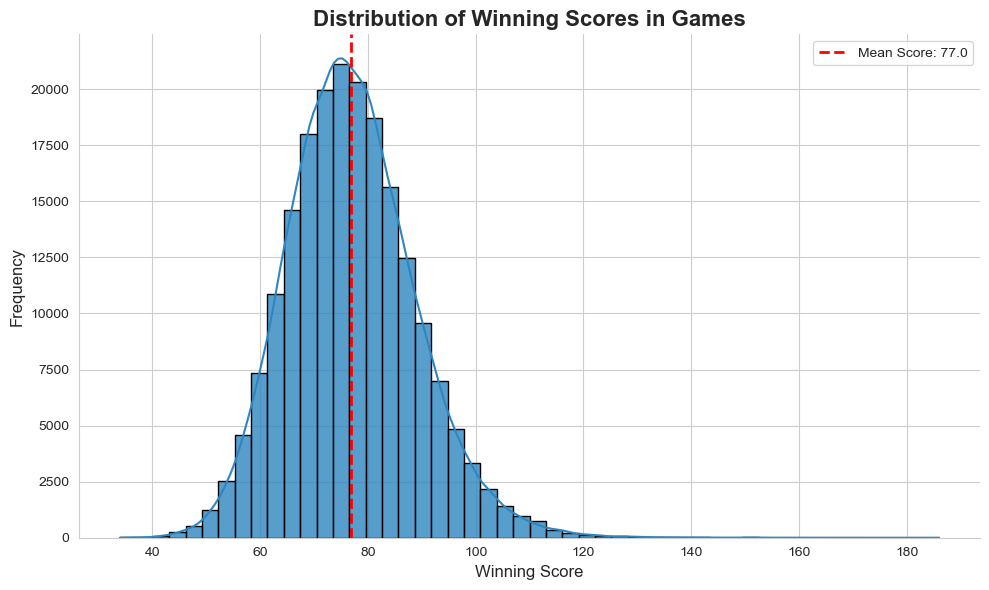

In [3]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
 
sns.histplot(games["WScore"], 
             bins=50, 
             kde=True, 
             color="#2E86C1",
             edgecolor="black",
             alpha=0.8)
 
mean_score = games["WScore"].mean()
 
plt.axvline(mean_score, 
            color="red", 
            linestyle="--", 
            linewidth=2, 
            label=f"Mean Score: {mean_score:.1f}")
 
plt.title("Distribution of Winning Scores in Games", fontsize=16, fontweight="bold")
plt.xlabel("Winning Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
 
sns.despine()
 
plt.legend()

plt.tight_layout()
plt.show()

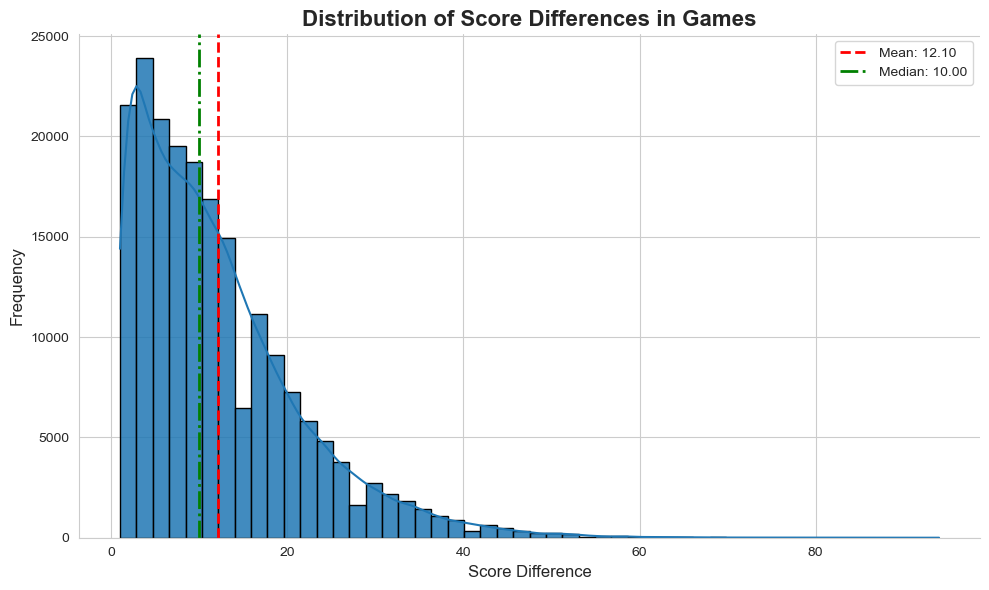

In [4]:
 sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
 
sns.histplot(games["ScoreDiff"],
             bins=50,
             kde=True,
             color="#1f77b4",
             edgecolor="black",
             alpha=0.85)
 
mean_diff = games["ScoreDiff"].mean()
median_diff = games["ScoreDiff"].median()
 
plt.axvline(mean_diff, color="red", linestyle="--", linewidth=2,
            label=f"Mean: {mean_diff:.2f}")

plt.axvline(median_diff, color="green", linestyle="-.", linewidth=2,
            label=f"Median: {median_diff:.2f}")
 
plt.title("Distribution of Score Differences in Games",
          fontsize=16, fontweight="bold")

plt.xlabel("Score Difference", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
 
sns.despine()
 
plt.legend()

plt.tight_layout()
plt.show()

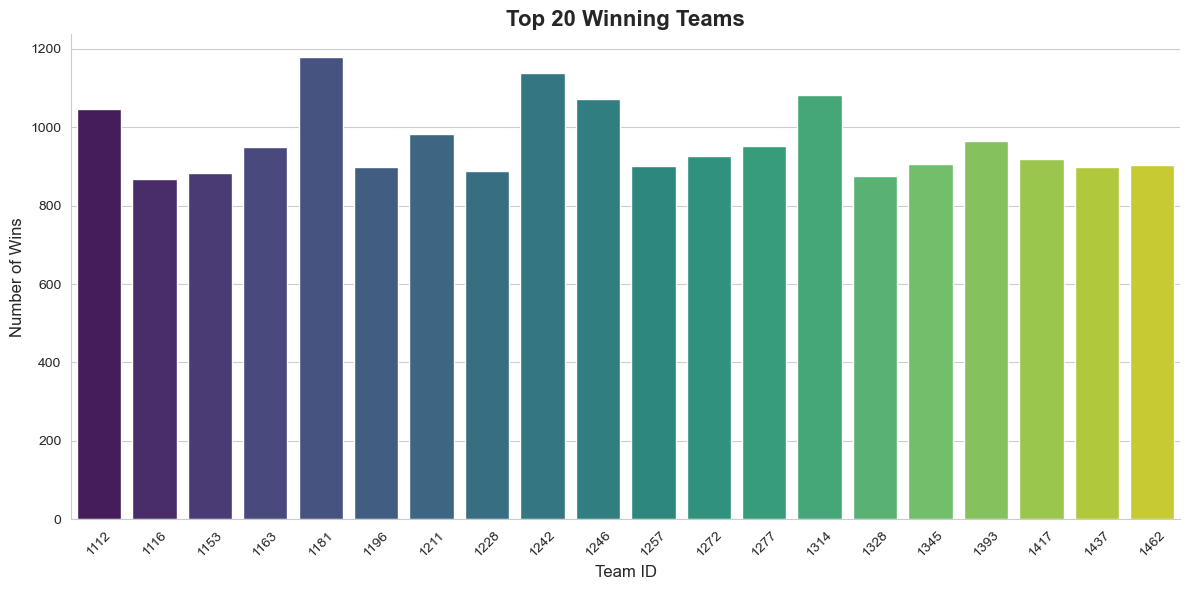

In [5]:
 wins = games["WTeamID"].value_counts().head(20)

sns.set_style("whitegrid")

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=wins.index,    
    y=wins.values,
    palette="viridis"
)
 
plt.title("Top 20 Winning Teams", fontsize=16, fontweight="bold")

plt.xlabel("Team ID", fontsize=12)
plt.ylabel("Number of Wins", fontsize=12)
 
plt.xticks(rotation=45)

sns.despine()

plt.tight_layout()
plt.show()

In [6]:
team_stats = games.groupby("WTeamID").agg({

    "WScore":"mean",
    "ScoreDiff":"mean"

}).reset_index()

team_stats.columns = [
    "TeamID",
    "AvgScore",
    "AvgDiff"
]

In [7]:
teams = pd.concat([
    games["WTeamID"],
    games["LTeamID"]
]).unique()

team_strength = {t:0 for t in teams}

for _,row in games.iterrows():

    team_strength[row["WTeamID"]] += 1
    team_strength[row["LTeamID"]] -= 1

In [8]:
elo = {team:1500 for team in teams}

K = 25

def expected(a,b):

    return 1/(1+10**((b-a)/400))

for _,row in games.iterrows():

    w = row["WTeamID"]
    l = row["LTeamID"]

    Ra = elo[w]
    Rb = elo[l]

    Ea = expected(Ra,Rb)
    Eb = expected(Rb,Ra)

    elo[w] = Ra + K*(1-Ea)
    elo[l] = Rb + K*(0-Eb)

In [36]:
sample_df = data["SampleSubmissionStage2"].copy()

pairs = []

for match_id in sample_df["ID"]:
    season, t1, t2 = match_id.split("_")
    t1 = int(t1)
    t2 = int(t2)

    elo1 = elo.get(t1, 1500)
    elo2 = elo.get(t2, 1500)
    s1 = team_strength.get(t1, 0)
    s2 = team_strength.get(t2, 0)

    pairs.append([
        elo1,
        elo2,
        elo1 - elo2,
        s1,
        s2
    ])

testX = pd.DataFrame(
    pairs,
    columns=["Elo1", "Elo2", "EloDiff", "Strength1", "Strength2"]
)

predictions = []
for model in models:
    predictions.append(model.predict_proba(testX)[:, 1])

pred = np.mean(predictions, axis=0)

submission = sample_df.copy()
submission["Pred"] = pred

submission.to_csv("Submission.csv", index=False)

print(len(sample_df))
print(len(testX))
print(len(submission))
submission.head()

132133
132133
132133


,ID,Pred
0,2026_1101_1102,0.743056
1,2026_1101_1103,0.417896
2,2026_1101_1104,0.179716
3,2026_1101_1105,0.737820
4,2026_1101_1106,0.603732


In [37]:
X = train.drop("Target",axis=1)
y = train["Target"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = [

LogisticRegression(),

RandomForestClassifier(n_estimators=300),

ExtraTreesClassifier(n_estimators=300),

GradientBoostingClassifier(),

KNeighborsClassifier(),

GaussianNB(),

SVC(probability=True, max_iter=100),

]

In [38]:
from sklearn.metrics import brier_score_loss
import gc

X = train.drop("Target",axis=1)
y = train["Target"]

ensemble_pred = np.zeros(len(X))

n_models = len(models)

for model in models:

    print("Training:", model.__class__.__name__)

    model.fit(X,y)

    pred = model.predict_proba(X)[:,1]

    ensemble_pred += pred / n_models

    del model
    gc.collect()

print("Brier Score:", brier_score_loss(y,ensemble_pred))

Training: LogisticRegression
Training: RandomForestClassifier
Training: ExtraTreesClassifier
Training: GradientBoostingClassifier
Training: KNeighborsClassifier
Training: GaussianNB
Training: SVC
Brier Score: 0.1991437320047284


In [39]:
sample_df =  data["SampleSubmissionStage2"].copy()

print("Sample rows:", len(sample_df))
sample_df.head()

Sample rows: 132133


,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5


In [41]:
pairs = []

for match_id in sample_df["ID"]:
    season, t1, t2 = match_id.split("_")
    t1 = int(t1)
    t2 = int(t2)

    elo1 = elo.get(t1, 1500)
    elo2 = elo.get(t2, 1500)
    s1 = team_strength.get(t1, 0)
    s2 = team_strength.get(t2, 0)

    pairs.append([
        elo1,
        elo2,
        elo1 - elo2,
        s1,
        s2
    ])

testX = pd.DataFrame(
    pairs,
    columns=["Elo1", "Elo2", "EloDiff", "Strength1", "Strength2"]
)

predictions = []
for model in models:
    predictions.append(model.predict_proba(testX)[:, 1])

pred = np.mean(predictions, axis=0)

submission = sample_df.copy()
submission["Pred"] = pred

print("sample_df rows:", len(sample_df))
print("testX rows:", len(testX))
print("pred rows:", len(pred))
print("submission rows:", len(submission))

submission.head()

sample_df rows: 132133
testX rows: 132133
pred rows: 132133
submission rows: 132133


,ID,Pred
0,2026_1101_1102,0.745004
1,2026_1101_1103,0.426761
2,2026_1101_1104,0.176876
3,2026_1101_1105,0.735794
4,2026_1101_1106,0.595928


In [42]:
submission.to_csv("Submission.csv", index=False)

In [43]:
submission.head(20)

,ID,Pred
0,2026_1101_1102,0.745004
1,2026_1101_1103,0.426761
2,2026_1101_1104,0.176876
3,2026_1101_1105,0.735794
4,2026_1101_1106,0.595928
5,2026_1101_1107,0.498080
6,2026_1101_1108,0.791986
7,2026_1101_1110,0.464316
8,2026_1101_1111,0.546364
9,2026_1101_1112,0.143657


In [44]:
submission.to_csv("submission.csv",index=False)

In [45]:
import random

teams = list(elo.keys())

def predict_game(team1, team2):

    features = [[
        elo[team1],
        elo[team2],
        elo[team1]-elo[team2],
        team_strength[team1],
        team_strength[team2]
    ]]
    
    prob = models[0].predict_proba(features)[0][1]
    
    if random.random() < prob:
        return team1
    else:
        return team2


def simulate_tournament():

    remaining = teams.copy()
    
    while len(remaining) > 1:
        
        random.shuffle(remaining)
        
        winners = []
        
        for i in range(0, len(remaining)-1, 2):
            
            team1 = remaining[i]
            team2 = remaining[i+1]
            
            winner = predict_game(team1, team2)
            
            winners.append(winner)
        
        remaining = winners
    
    return remaining[0]

In [46]:
n_simulations = 1000

champions = {}

for team in teams:
    champions[team] = 0

for i in range(n_simulations):

    champ = simulate_tournament()
    
    champions[champ] += 1

In [47]:
results = []

for team,count in champions.items():
    
    prob = (count / n_simulations) * 100
    
    results.append((team,prob))

results = sorted(results, key=lambda x: x[1], reverse=True)

top10 = results[:10]

for i,(team,prob) in enumerate(top10,1):
    
    print(i,"Team",team,"→",round(prob,2),"% chance to win")

1 Team 1181 → 12.7 % chance to win
2 Team 1242 → 9.0 % chance to win
3 Team 1314 → 6.6 % chance to win
4 Team 1246 → 6.2 % chance to win
5 Team 1163 → 6.0 % chance to win
6 Team 1112 → 4.7 % chance to win
7 Team 1211 → 4.2 % chance to win
8 Team 1393 → 3.2 % chance to win
9 Team 1277 → 3.1 % chance to win
10 Team 1196 → 2.6 % chance to win
